1D CNN Autoencoder architecture trained using k-Fold validation method for avoiding overfitting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, UpSampling1D, MaxPooling1D, Dense, Flatten, Reshape
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

dataset = pd.read_csv(r"C:\Users\Admin\Desktop\CP\Data\processed\final_processed\GAIT_analysis_dataset.csv")

hip_cols = [col for col in dataset.columns if "aSagH_" in col] 
knee_cols = [col for col in dataset.columns if "aSagK_" in col]

hip_data = dataset[hip_cols].to_numpy()
knee_data = dataset[knee_cols].to_numpy()

print("hip_data shape:",hip_data.shape)
print("knee_data shape:",knee_data.shape)


hip_data shape: (551, 51)
knee_data shape: (551, 51)


In [161]:
X_hip, y_hip = create_sliding_window_dataset(hip_data,window_size=19,step=5) #for window size = 15 step = 5 : shape (2755, 15). for window size = 19 step = 5 : shape (1653,19)
X_knee, y_knee = create_sliding_window_dataset(knee_data,window_size=19,step=5)#for window size = 15 step = 5 : shape (2755, 15). for window size = 19 step = 5 : shape (1653,19)
#scaler = MinMaxScaler() #normalization
'''
X_hip = scaler.fit_transform(X_hip)
y_hip = scaler.fit_transform(y_hip)
X_knee = scaler.fit_transform(X_knee)
y_knee = scaler.fit_transform(y_knee)
#nan value in X_knee and y_knee

X_knee = np.nan_to_num(X_knee, nan=0.0, posinf=0.0, neginf=0.0)
y_knee = np.nan_to_num(y_knee, nan=0.0, posinf=0.0, neginf=0.0)
#Reshape data for model input
X_hip = X_hip[...,np.newaxis]
y_hip = y_hip[...,np.newaxis]
X_knee = X_knee[...,np.newaxis]
y_knee = y_knee[...,np.newaxis] #adds a new dimension (samples, timesteps, features)'''

'\nX_hip = scaler.fit_transform(X_hip)\ny_hip = scaler.fit_transform(y_hip)\nX_knee = scaler.fit_transform(X_knee)\ny_knee = scaler.fit_transform(y_knee)\n#nan value in X_knee and y_knee\n\nX_knee = np.nan_to_num(X_knee, nan=0.0, posinf=0.0, neginf=0.0)\ny_knee = np.nan_to_num(y_knee, nan=0.0, posinf=0.0, neginf=0.0)\n#Reshape data for model input\nX_hip = X_hip[...,np.newaxis]\ny_hip = y_hip[...,np.newaxis]\nX_knee = X_knee[...,np.newaxis]\ny_knee = y_knee[...,np.newaxis] #adds a new dimension (samples, timesteps, features)'

In [162]:
X_knee = np.nan_to_num(X_knee, nan=0.0, posinf=0.0, neginf=0.0)#knee had Nan value
y_knee = np.nan_to_num(y_knee, nan=0.0, posinf=0.0, neginf=0.0)

In [163]:
def normalize_sequences(X):
    scaler = MinMaxScaler()
    # Normalize each sample (sequence) independently, assuming X shape = (samples, timesteps)
    X_norm = np.array([scaler.fit_transform(seq.reshape(-1, 1)).flatten() for seq in X])
    return X_norm

# Apply it on your data, then add back the feature dimension
X_hip = normalize_sequences(X_hip.squeeze())[..., np.newaxis]
y_hip = normalize_sequences(y_hip.squeeze())[..., np.newaxis]
X_knee = normalize_sequences(X_knee.squeeze())[..., np.newaxis]
y_knee = normalize_sequences(y_knee.squeeze())[..., np.newaxis]

In [164]:
def get_window_patient_ids(patient_ids_seq, full_sequence_length, window_size, step=1):
    window_patient_ids = []
    for pid in patient_ids_seq:
        num_windows = (full_sequence_length - 2 * window_size) // step + 1
        window_patient_ids.extend([pid] * num_windows)
    return np.array(window_patient_ids)


In [165]:
patient_ids = dataset['Patient ID'].to_numpy()  # shape: (num_sequences,)
window_size = 19
step = 5
full_sequence_length = hip_data.shape[1]  # length of each full sequence in timesteps, e.g., 60

window_patient_ids = get_window_patient_ids(patient_ids_seq=patient_ids, 
                                            full_sequence_length=full_sequence_length, 
                                            window_size=window_size, 
                                            step=step)

In [166]:
#Model Building
class CNN_Autoencoder(Model):
    def __init__(self, 
                 latent_dim=64, 
                 conv_filters=[64, 128, 256], 
                 kernel_size=3, 
                 strides=2, 
                 activation='relu'):
        super(CNN_Autoencoder, self).__init__()

        self.latent_dim = latent_dim
        self.activation = activation
        self.conv_filters = conv_filters
        self.kernel_size = kernel_size
        self.strides = strides

        # Encoder layers
        self.encoder_layers = [
            layers.Conv1D(f, kernel_size, strides=strides, padding='same', activation=activation)
            for f in conv_filters
        ]
        
        self.flatten = layers.Flatten()
        self.bottleneck = layers.Dense(latent_dim, activation=activation)

        # Decoder layers (created later in build())
        self.decoder_layers = []
        self.dense = None
        self.reshape_layer = None
        self.output_layer = None

    def build(self, input_shape):
        # Apply encoder to dummy input to get output shape
        x = layers.Input(shape=input_shape[1:])
        z = x
        for layer in self.encoder_layers:
            z = layer(z)

        encoded_shape = z.shape  # [None, reduced_timesteps, channels]
        self.encoded_timesteps = encoded_shape[1]
        self.encoded_channels = encoded_shape[2]

        # Decoder layers now that we know the shape
        self.dense = layers.Dense(self.encoded_timesteps * self.encoded_channels, activation=self.activation)
        self.reshape_layer = layers.Reshape((self.encoded_timesteps, self.encoded_channels))

        # Mirror the conv filters for decoder
        for f in reversed(self.conv_filters):
            self.decoder_layers.append(
                layers.Conv1DTranspose(f, self.kernel_size, strides=self.strides, padding='same', activation=self.activation)
            )

        self.output_layer = layers.Conv1D(1, self.kernel_size, padding='same', activation='linear')
        
        super().build(input_shape)  # Let Keras know the model is built

    def encode(self, inputs):
        x = inputs
        for layer in self.encoder_layers:
            x = layer(x)
        x = self.flatten(x)
        x = self.bottleneck(x)
        return x


    def call(self, inputs):
        x = inputs
        for layer in self.encoder_layers:
            x = layer(x)
        x = self.flatten(x)
        x = self.bottleneck(x)
        x = self.dense(x)
        x = self.reshape_layer(x)
        for layer in self.decoder_layers:
            x = layer(x)
        x = self.output_layer(x)

        # Crop or slice to match input timesteps
        x = x[:, :inputs.shape[1], :]  # Ensure final output is same length as input
        return x

In [167]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42) #kfolds 


Fold 1
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1899 - val_loss: 0.0451
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0412 - val_loss: 0.0282
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0257 - val_loss: 0.0184
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0226 - val_loss: 0.0172
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0176 - val_loss: 0.0174
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0189 - val_loss: 0.0165
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0172 - val_loss: 0.0158
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0176 - val_loss: 0.0157
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0187 - val_loss: 0.0149
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0176 - val_loss: 0.0141
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0161 - val_loss: 0.0143
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - l

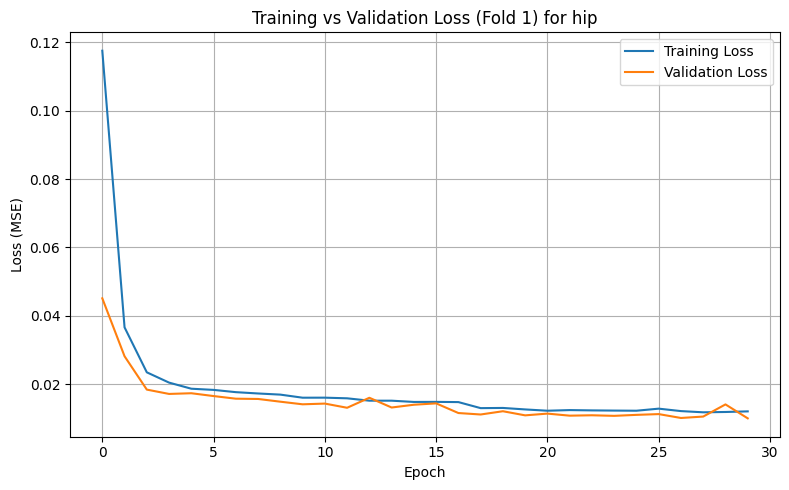


Fold 2
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.1798 - val_loss: 0.0455
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0408 - val_loss: 0.0295
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0254 - val_loss: 0.0194
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0191 - val_loss: 0.0209
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0187 - val_loss: 0.0175
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0163 - val_loss: 0.0167
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0170 - val_loss: 0.0161
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0160 - val_loss: 0.0200
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0169 - val_loss: 0.0155
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0134 - val_loss: 0.0148
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0146 - val_loss: 0.0147
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - l

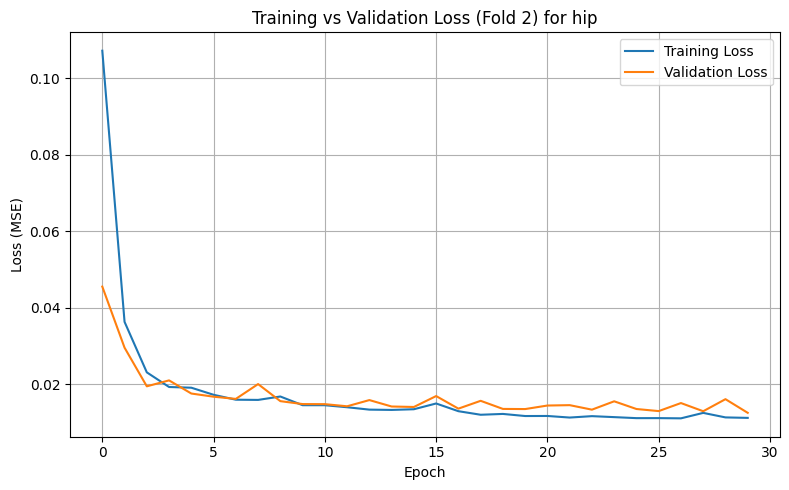


Fold 3
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.1907 - val_loss: 0.0370
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0331 - val_loss: 0.0201
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0176 - val_loss: 0.0180
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0177 - val_loss: 0.0183
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0194 - val_loss: 0.0164
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0159 - val_loss: 0.0161
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0171 - val_loss: 0.0160
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0157 - val_loss: 0.0155
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0180 - val_loss: 0.0151
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0141 - val_loss: 0.0144
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0149 - val_loss: 0.0144
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - l

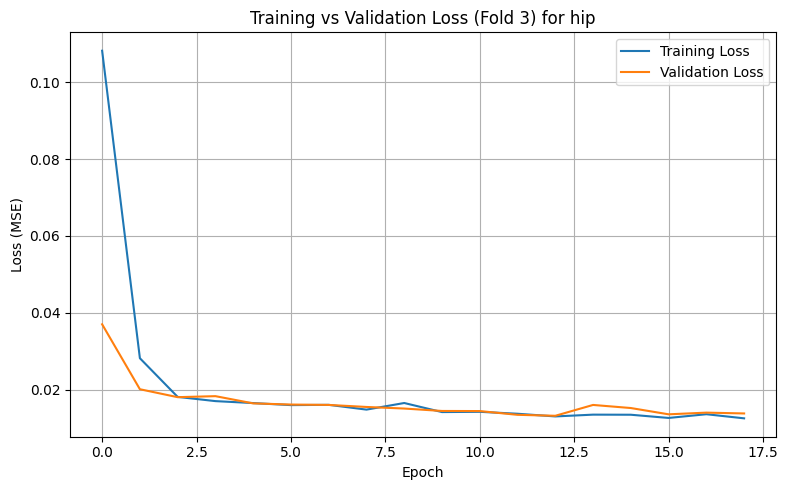


Fold 1
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.2621 - val_loss: 0.0503
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0448 - val_loss: 0.0288
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0291 - val_loss: 0.0262
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0258 - val_loss: 0.0232
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0269 - val_loss: 0.0239
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0223 - val_loss: 0.0206
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0207 - val_loss: 0.0187
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0203 - val_loss: 0.0218
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0227 - val_loss: 0.0176
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0170 - val_loss: 0.0176
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0191 - val_loss: 0.0185
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - l

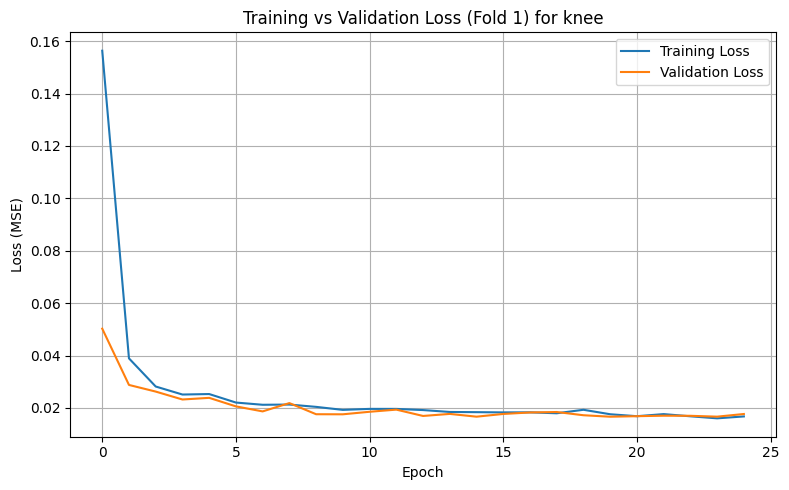


Fold 2
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.2390 - val_loss: 0.0508
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0424 - val_loss: 0.0327
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0274 - val_loss: 0.0263
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0232 - val_loss: 0.0256
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0211 - val_loss: 0.0232
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0216 - val_loss: 0.0238
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0202 - val_loss: 0.0224
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0212 - val_loss: 0.0209
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0198 - val_loss: 0.0205
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0188 - val_loss: 0.0210
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0176 - val_loss: 0.0213
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - l

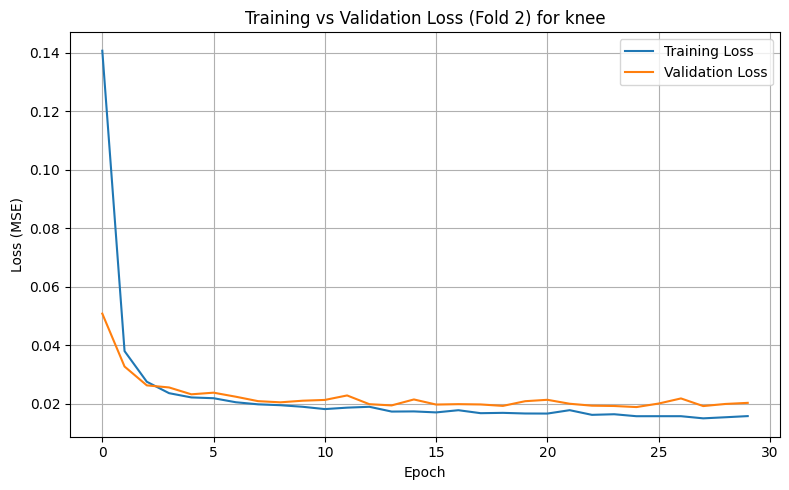


Fold 3
Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.2960 - val_loss: 0.0551
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0466 - val_loss: 0.0333
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0293 - val_loss: 0.0253
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0264 - val_loss: 0.0258
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0247 - val_loss: 0.0225
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0224 - val_loss: 0.0220
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0221 - val_loss: 0.0219
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0217 - val_loss: 0.0213
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0207 - val_loss: 0.0213
Epoch 10/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0198 - val_loss: 0.0208
Epoch 11/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0187 - val_loss: 0.0214
Epoch 12/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - l

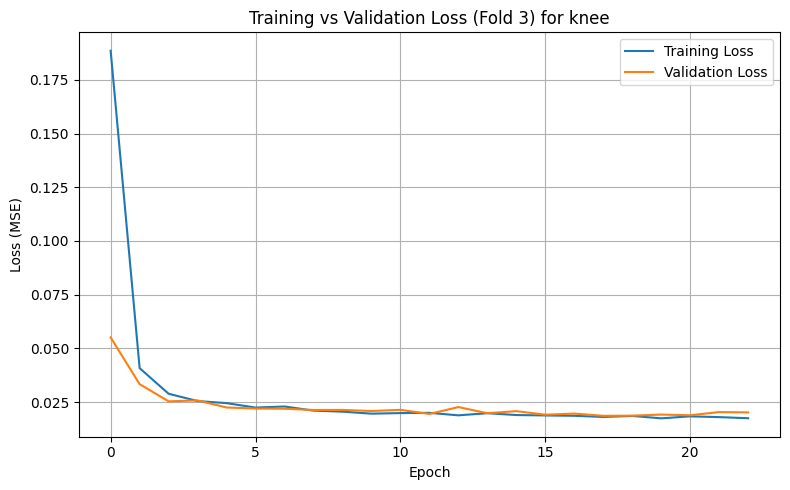

In [168]:
#training
#for hip

all_latent_vectors_hip = []
all_latent_vectors_knee = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_hip)):
    print(f"\nFold {fold+1}")
    model_hip = CNN_Autoencoder(latent_dim=32,conv_filters=[32,64,128])  # pass hyperparameters

    # compile model
    model_hip.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # fit model on hip
    history_hip = model_hip.fit(X_hip[train_idx], y_hip[train_idx],
              validation_data=(X_hip[val_idx], y_hip[val_idx]),
              epochs=30, batch_size=32, verbose=1,callbacks=[early_stop])
    
    # Encode validation data for this fold
    latent_vecs_val_hip = model_hip.encode(X_hip[val_idx]).numpy()
    all_latent_vectors_hip.append((val_idx, latent_vecs_val_hip))
    
    # Plotting loss
    plt.figure(figsize=(8, 5))
    plt.plot(history_hip.history['loss'], label='Training Loss')
    plt.plot(history_hip.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(f'Training vs Validation Loss (Fold {fold+1}) for hip')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
#for knee
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_knee)):
    print(f"\nFold {fold+1}")
    model_knee = CNN_Autoencoder(latent_dim=32,conv_filters=[32,64,128])  # pass hyperparameters

    # compile model
    model_knee.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # fit model on hip
    history_knee = model_knee.fit(X_knee[train_idx], y_knee[train_idx],
              validation_data=(X_knee[val_idx], y_knee[val_idx]),
              epochs=30, batch_size=32, verbose=1,callbacks=[early_stop])
    
    latent_vecs_val_knee = model_hip.encode(X_knee[val_idx]).numpy()
    all_latent_vectors_knee.append((val_idx, latent_vecs_val_knee))
    
    # Plotting loss
    plt.figure(figsize=(8, 5))
    plt.plot(history_knee.history['loss'], label='Training Loss')
    plt.plot(history_knee.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(f'Training vs Validation Loss (Fold {fold+1}) for knee')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    


In [169]:
all_latent_vectors_hip = sorted(all_latent_vectors_hip, key=lambda x: x[0][0])
latent_vectors_hip = np.vstack([vec for _, vec in all_latent_vectors_hip])

all_latent_vectors_knee = sorted(all_latent_vectors_knee, key=lambda x: x[0][0])
latent_vectors_knee = np.vstack([vec for _, vec in all_latent_vectors_knee])

In [170]:
#concatenate
combined_latent_vectors = np.hstack([latent_vectors_hip, latent_vectors_knee])

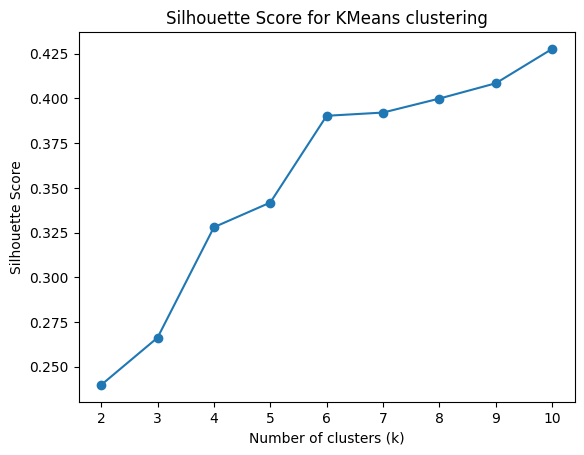

Best k: 10
  patient_id  cluster
0          1        3
1          1        2
2          1        3
3          2        6
4          2        3


In [171]:
# Confirm patient_ids length matches your latent vectors
assert len(window_patient_ids) == combined_latent_vectors.shape[0], "Mismatch in number of samples and patient IDs"

# Find best k using silhouette score
silhouette_scores = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(combined_latent_vectors)
    score = silhouette_score(combined_latent_vectors, labels)
    silhouette_scores.append(score)

plt.plot(k_values, silhouette_scores, 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for KMeans clustering')
plt.show()

best_k = k_values[np.argmax(silhouette_scores)]
print(f"Best k: {best_k}")

# Cluster with best k
kmeans = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans.fit_predict(combined_latent_vectors)

# Create DataFrame with patient IDs and cluster labels per window
df_clusters = pd.DataFrame({
    'patient_id': window_patient_ids,
    'cluster': cluster_labels
})

print(df_clusters.head())
